In [1]:
import numpy as np

# import sasmodels
import sasmodels
from sasmodels import weights

import os

"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


import matplotlib.pyplot as plt
#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('svg')

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

plt.rc('image', cmap='jet')


In [2]:
from scipy.integrate import quad

* add Maier-Saupe to the weights
* SASView implementation
* two slightly different functions

In [3]:
import sasmodels.weights
sasmodels.weights.load_weights('maier_saupe.py')
sasmodels.weights.load_weights('maier_saupe_eq.py')

* add Maier-Saupe and compute_S
* Nicolas implementation

In [4]:
def Z_MS(m, x0):
        """Normalization constant for Maier-Saupe distribution."""
        beta0 = np.radians(x0)
        integrand = lambda beta: np.exp(m * np.cos(beta - beta0)**2) * np.sin(beta)
        Z, _ = quad(integrand, 0, np.pi, epsabs=1e-12, epsrel=1e-12)
        return Z
    

def ms_distribution(beta, m, x0):
    """Normalized Maier-Saupe distribution."""
    beta0 = np.radians(x0)
    D = np.exp(m * np.cos(beta - beta0)**2)
    return D / Z_MS(m, x0)
   

In [5]:
def compute_S(m, x0):
        """Compute nematic order parameter S from Maier-Saupe parameters."""
        num_integrand = lambda theta: (0.5 * (3*np.cos(theta - np.radians(x0))**2 - 1)) \
                                    * np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)
        den_integrand = lambda theta: np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)

        num, _ = quad(num_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)
        den, _ = quad(den_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)

        return num / den

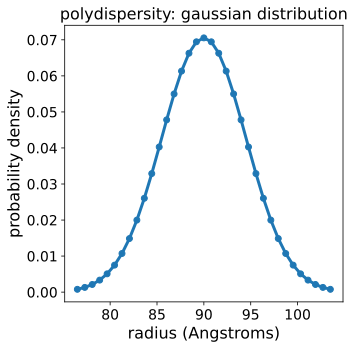

In [41]:
distribution = "gaussian"

# The probability density function can be accessed using the weights.get_weights() method in sasmodels
pdf = sasmodels.weights.get_weights(
    distribution,
    n=35,               # _pd_n parameter
    width=0.05,          # this is equal to _pd parameter, or sigma/x_mean
    nsigmas=3,          # _pd_nsigma parameter
    value=90,          # corresponds to x_mean, or the value of the parameter to which polydispersity is applied, in this case it is the radius
    limits=[-np.inf, np.inf], # hard limit on the possible values (can't have negative radius)
    relative=True       # set to true if width is in proportion to the parameter value, or x_mean in this case
)

plt.errorbar(pdf[0], pdf[1], fmt='o-')
plt.xlabel("radius (Angstroms)")
plt.ylabel("probability density")
plt.title(f"polydispersity: {distribution} distribution")
plt.show()



In [21]:
print(pdf)

(array([ 76.5       ,  77.29411765,  78.08823529,  78.88235294,
        79.67647059,  80.47058824,  81.26470588,  82.05882353,
        82.85294118,  83.64705882,  84.44117647,  85.23529412,
        86.02941176,  86.82352941,  87.61764706,  88.41176471,
        89.20588235,  90.        ,  90.79411765,  91.58823529,
        92.38235294,  93.17647059,  93.97058824,  94.76470588,
        95.55882353,  96.35294118,  97.14705882,  97.94117647,
        98.73529412,  99.52941176, 100.32352941, 101.11764706,
       101.91176471, 102.70588235, 103.5       ]), array([0.00078365, 0.00131002, 0.00212282, 0.00333443, 0.00507698,
       0.00749315, 0.01072011, 0.01486651, 0.01998453, 0.0260408 ,
       0.03289196, 0.04027176, 0.04779547, 0.05498548, 0.06131753,
       0.06628214, 0.06945182, 0.07054171, 0.06945182, 0.06628214,
       0.06131753, 0.05498548, 0.04779547, 0.04027176, 0.03289196,
       0.0260408 , 0.01998453, 0.01486651, 0.01072011, 0.00749315,
       0.00507698, 0.00333443, 0.00212282,

### compute S from the average of cos**2
* from the weighted distribution


In [42]:
cos2ave=0
meanvalue=100

for i in range(len(pdf[0])):
    angle=pdf[0][i]-meanvalue
    cos2ave+=pdf[1][i]*(np.cos(angle*np.pi/180))**2


print(cos2ave)

S=(3*cos2ave-1)/2

print(S)

0.9642028436901628
0.9463042655352443


In [65]:
for angle in pdf[0]:
    print(angle)

0.0
5.882352941176464
11.764705882352942
17.64705882352942
23.529411764705884
29.411764705882348
35.294117647058826
41.1764705882353
47.05882352941177
52.94117647058824
58.82352941176471
64.70588235294119
70.58823529411765
76.47058823529412
82.3529411764706
88.23529411764707
94.11764705882354
100.0
105.88235294117648
111.76470588235296
117.64705882352942
123.52941176470588
129.41176470588238
135.29411764705884
141.1764705882353
147.05882352941177
152.94117647058823
158.82352941176472
164.7058823529412
170.58823529411765
176.47058823529414
182.3529411764706
188.23529411764707
194.11764705882354
200.0


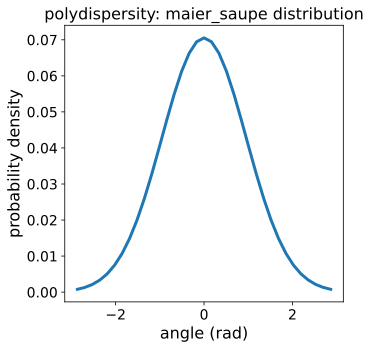

In [54]:
distribution = "maier_saupe"

m_para=20
# The probability density function can be accessed using the weights.get_weights() method in sasmodels
pdf_ms = sasmodels.weights.get_weights(
    distribution,
    n=35,               # _pd_n parameter
    width=m_para,          # this is equal to _pd parameter, or sigma/x_mean
    nsigmas=3,          # _pd_nsigma parameter
    value=90,          # corresponds to x_mean, or the value of the parameter to which polydispersity is applied, in this case it is the radius
    limits=[0, np.inf], # hard limit on the possible values (can't have negative radius)
    relative=True       # set to true if width is in proportion to the parameter value, or x_mean in this case
)

#plt.errorbar(pdf[0], pdf[1], fmt='o-')
plt.plot(pdf_ms[0], pdf_ms[1])
plt.xlabel("angle (rad)")
plt.ylabel("probability density")
plt.title(f"polydispersity: {distribution} distribution")

xvalues=np.linspace(-np.pi/2,np.pi/2,100)

x0=0

m=m_para*np.pi/180

yvalues=[ms_distribution(x, m, x0) for x in xvalues]


#plt.plot(xvalues,yvalues)

plt.show()

In [55]:
print(pdf_ms)

(array([-2.86478898, -2.69627198, -2.52775498, -2.35923798, -2.19072098,
       -2.02220398, -1.85368698, -1.68516999, -1.51665299, -1.34813599,
       -1.17961899, -1.01110199, -0.84258499, -0.67406799, -0.505551  ,
       -0.337034  , -0.168517  ,  0.        ,  0.168517  ,  0.337034  ,
        0.505551  ,  0.67406799,  0.84258499,  1.01110199,  1.17961899,
        1.34813599,  1.51665299,  1.68516999,  1.85368698,  2.02220398,
        2.19072098,  2.35923798,  2.52775498,  2.69627198,  2.86478898]), array([0.00078649, 0.00131372, 0.00212738, 0.00333976, 0.00508285,
       0.00749918, 0.01072579, 0.0148713 , 0.01998788, 0.02604228,
       0.03289134, 0.040269  , 0.04779075, 0.05497914, 0.06130998,
       0.06627378, 0.06944301, 0.07053276, 0.06944301, 0.06627378,
       0.06130998, 0.05497914, 0.04779075, 0.040269  , 0.03289134,
       0.02604228, 0.01998788, 0.0148713 , 0.01072579, 0.00749918,
       0.00508285, 0.00333976, 0.00212738, 0.00131372, 0.00078649]))


### compute S from the average of cos**2
* from the weighted distribution

In [56]:
cos2ave_ms=0
meanvalue_ms=0

for i in range(len(pdf_ms[0])):
    angle_ms=pdf_ms[0][i]-meanvalue_ms
#    cos2ave_ms+=pdf_ms[1][i]*(np.cos(angle_ms*np.pi/180))**2
    cos2ave_ms+=pdf_ms[1][i]*(np.cos(angle_ms))**2


print(cos2ave_ms)

S=(3*cos2ave_ms-1)/2

print(S)

0.5799473589312827
0.36992103839692403


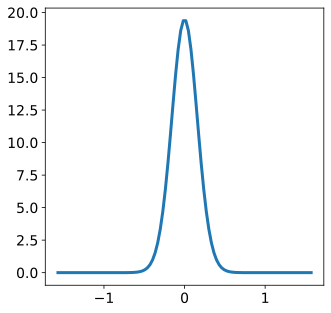

In [57]:
xvalues=np.linspace(-np.pi/2,np.pi/2,100)

x0=0

m=m_para

yvalues=[ms_distribution(x, m, x0) for x in xvalues]


plt.plot(xvalues,yvalues)


In [59]:
norm=np.sum(yvalues)
print(norm)

246.41645528099758


In [60]:
cos2ave=0
meanvalue=0

norm=np.sum(yvalues)

for i in range(len(xvalues)):
    angle=xvalues[i]-meanvalue
    cos2ave+=yvalues[i]*(np.cos(xvalues[i]))**2
    cos2ave=cos2ave/norm


print(cos2ave)

S=(3*cos2ave-1)/2

print(S)

6.906853231113411e-16
-0.49999999999999895


In [27]:
print(ms_distribution(0., m_para, 0.))


0.5702880319265736


1.0


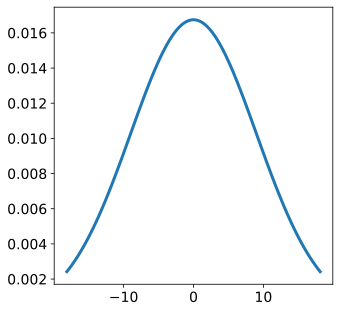

In [31]:
values=sasmodels.weights.get_weights('maier_saupe',    
    n=100,       # _pd_n parameter
    width=0.2,         # this is equal to _pd parameter, or sigma/x_mean
    nsigmas=2,          # _pd_nsigma parameter
    value=100,          # corresponds to x_mean, or the value of the parameter to which polydispersity is applied, in this case it is the radius
    limits=[0, np.inf], # hard limit on the possible values (can't have negative radius)
    relative=True)

plt.plot(values[0],values[1])

print(np.sum(values[1]))